# Preprocessing

## 1. Imports and Setup

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Define folder path
data_folder = "data/"

# Define tract prefixes
treatment_prefixes = ["48113"]
control_prefixes = ["48201"]

# Define years
years = list(range(2014, 2023))

# Columns to keep
columns_to_keep = [
    "program_label",
    "program",
    "entities",
    "code",
    "number_reported",
    "rent_per_month",
    "hh_income",
    "tpoverty",
]

# Numeric columns
numeric_cols = ["number_reported", "rent_per_month", "hh_income", "tpoverty"]

# Missing / suppression codes
missing_codes = ["-1", "-4", "-5", "NA"]

suppression_threshold = 11

## 2. Helper Functions

In [2]:
def filter_tracts(df, treatment_prefixes, control_prefixes, file_name="unknown"):
    """
    Create treatment indicator and restrict dataset to relevant tracts.
    """
    try:
        # Ensure tract codes are strings
        df["code"] = df["code"].astype(str)

        # Create treatment indicator (1 if treatment prefix, 0 otherwise)
        df["treatment"] = (
            df["code"].str.startswith(tuple(treatment_prefixes)).astype(int)
        )

        # Keep only treatment and control tracts
        valid_prefixes = tuple(treatment_prefixes + control_prefixes)
        df = df[df["code"].str.startswith(valid_prefixes)]

        return df

    except Exception as e:
        print(f"error in filter_tracts for file: {file_name}")
        print(e)
        return df


def processing_missing_values(df, file_name="unknown"):
    """
    Clean dataset by handling numeric conversion, suppression, and missing values.
    """
    try:
        # Ensure code is string type for pattern matching
        df["code"] = df["code"].astype(str)

        # Replace all missing tract codes with NaN
        df.loc[df["code"].str.endswith("999999"), "code"] = np.nan

        # Convert outcome variable first
        df["number_reported"] = pd.to_numeric(df["number_reported"], errors="coerce")

        # Apply HUD suppression rule (< threshold treated as missing)
        df.loc[df["number_reported"] < suppression_threshold, "number_reported"] = (
            np.nan
        )

        # Replace known missing codes across dataset with NA
        df = df.replace(missing_codes, np.nan)

        # Convert numeric columns to integers 
        for col in numeric_cols:
            if col in df.columns:
                if "TRACT_MO_WY_2013.xlsx" in file_name:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
                else:
                    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")


        # Drop rows with any missing values
        df = df.dropna()

        return df

    except Exception as e:
        print(f"error in processing_missing_values for file: {file_name}")
        print(e)
        return df


def add_year(df, year):
    """
    Add a year identifier to the dataset.
    """
    df["year"] = year
    return df


def create_variables(df):
    """
    Create derived analysis variables.
    """
    # Post-treatment indicator (1 if year >= 2018)
    df["post"] = (df["year"] >= 2018).astype(int)

    # Poverty indicator (1 if tract poverty rate >= 30%)
    df["poverty_indicator"] = (df["tpoverty"] >= 30).astype(int)

    return df

## 3. Process HCV Data

In [ ]:
# Initialize a list to store the processed datasets
df_list = []

# Loop through and process the datasets
for year in years:
    pattern = os.path.join(data_folder, f"TRACT_*_{year}.xlsx")
    files = glob.glob(pattern)

    for file in files:
        try:
            print(f"Processing file: {file}")

            # Load file
            df = pd.read_excel(file, dtype=str)

            # Filter to HCV program
            df = df[df["program"] == "3"]

            # Keep only needed columns
            df = df[[col for col in columns_to_keep if col in df.columns]]

            # Filter tracts and assign treatment
            df = filter_tracts(df, treatment_prefixes, control_prefixes, file)

            # Process missing values
            df = processing_missing_values(df, file)

            # Add year
            df = add_year(df, year)

            # Warn if dataset becomes empty
            if df.empty:
                print(f"Warning: {file} resulted in empty dataframe after filtering")

            df_list.append(df)

        except Exception as e:
            print(f"Error processing file: {file} in main loop")
            print(e)

# Combine all files
panel_df = pd.concat(df_list, ignore_index=True)

# Create derived variables
panel_df = create_variables(panel_df)

Processing file: data\TRACT_MO_WY_2014.xlsx
Processing file: data\TRACT_MO_WY_2015.xlsx
Processing file: data\TRACT_MO_WY_2016.xlsx
Processing file: data\TRACT_MO_WY_2017.xlsx
Processing file: data\TRACT_MO_WY_2018.xlsx
Processing file: data\TRACT_MO_WY_2019.xlsx
Processing file: data\TRACT_MO_WY_2020.xlsx
Processing file: data\TRACT_MO_WY_2021.xlsx
Processing file: data\TRACT_MO_WY_2022.xlsx


In [ ]:
# Show a sample of the cleaned HCV dataset
panel_df.sample(5)

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
188,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113016607,48113016607,148,315,11142,25,1,2014,0,0
3264,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113009000,48113009000,118,400,15858,31,1,2019,1,1
2707,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113015205,48113015205,29,305,11448,31,1,2018,1,1
3090,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201453401,48201453401,24,347,12368,16,0,2018,1,0
3547,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201241300,48201241300,19,416,17778,9,0,2019,1,0


## 4. Exploratory Data Analysis

In [ ]:
# Show dimensions of the HCV dataset
panel_df.shape

(5703, 12)

In [6]:
# Show general information about the dataframe
panel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5703 entries, 0 to 5702
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   program_label      5703 non-null   str  
 1   program            5703 non-null   str  
 2   entities           5703 non-null   str  
 3   code               5703 non-null   str  
 4   number_reported    5703 non-null   Int64
 5   rent_per_month     5703 non-null   Int64
 6   hh_income          5703 non-null   Int64
 7   tpoverty           5703 non-null   Int64
 8   treatment          5703 non-null   int64
 9   year               5703 non-null   int64
 10  post               5703 non-null   int64
 11  poverty_indicator  5703 non-null   int64
dtypes: Int64(4), int64(4), str(4)
memory usage: 557.1 KB


In [7]:
# Show summary statistics
panel_df.describe()

,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
count,5703.0,5703.0,5703.0,5703.0,5703.000000,5703.000000,5703.000000,5703.000000
mean,69.22532,406.294932,14877.115027,22.038752,0.451692,2017.950377,0.547607,0.263546
std,73.954337,114.750762,3774.176319,12.202966,0.497705,2.589098,0.497772,0.440594
min,11.0,82.0,3198.0,0.0,0.000000,2014.000000,0.000000,0.000000
25%,22.0,325.0,12287.0,13.0,0.000000,2016.000000,0.000000,0.000000
50%,43.0,387.0,14298.0,20.0,0.000000,2018.000000,1.000000,0.000000
75%,88.0,475.0,17023.5,30.0,1.000000,2020.000000,1.000000,1.000000
max,681.0,1084.0,39600.0,79.0,1.000000,2022.000000,1.000000,1.000000


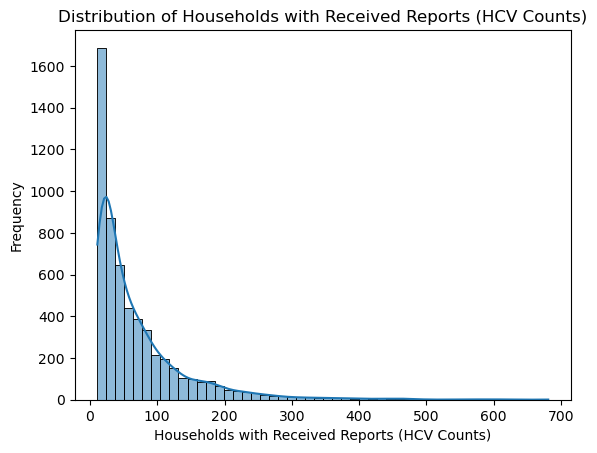

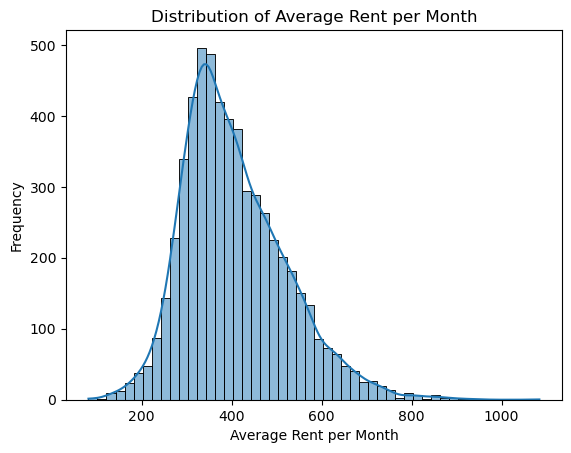

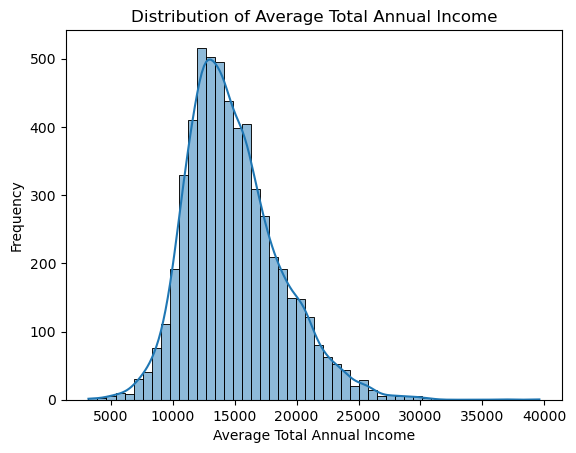

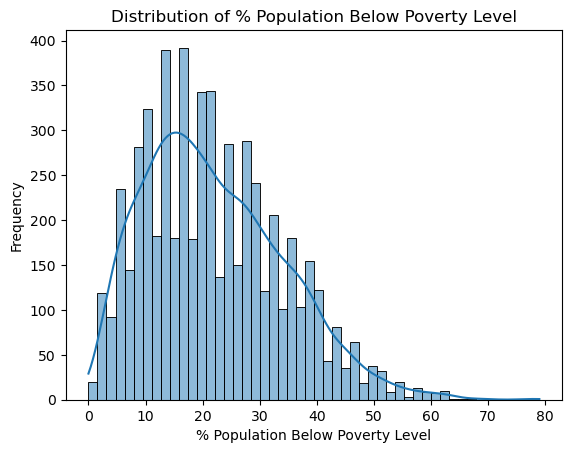

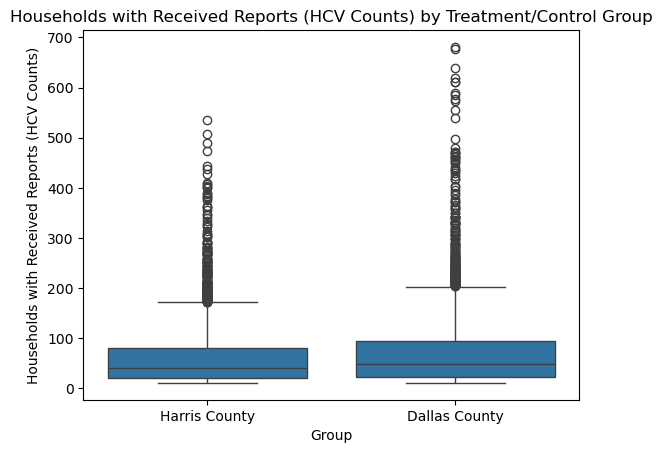

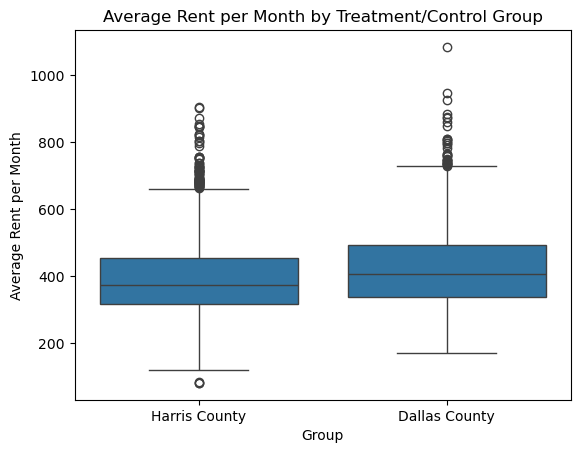

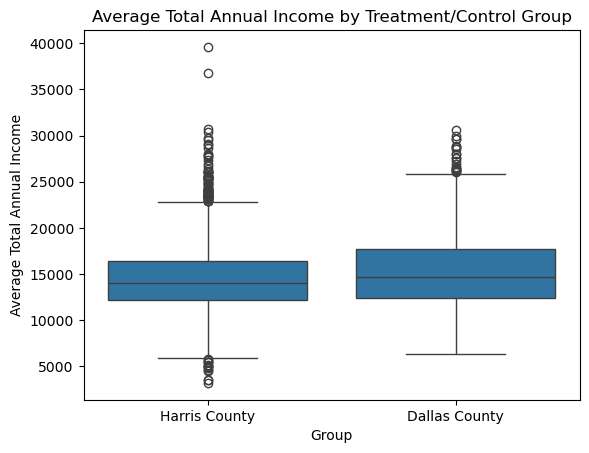

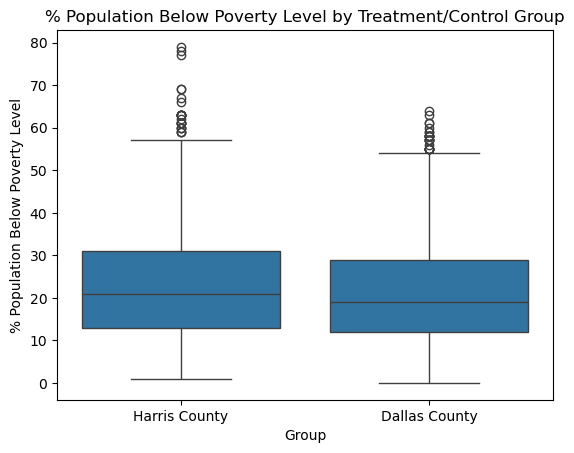

In [8]:
# Mapping of variable names to readable labels
labels = {
    "number_reported": "Households with Received Reports (HCV Counts)",
    "rent_per_month": "Average Rent per Month",
    "hh_income": "Average Total Annual Income",
    "tpoverty": "% Population Below Poverty Level"
}

# Plot Histograms
for col in numeric_cols:
    plt.figure()
    sns.histplot(panel_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {labels[col]}")
    plt.xlabel(labels[col])
    plt.ylabel("Frequency")
    plt.show()

# Plot Boxplots
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x="treatment", y=col, data=panel_df)
    plt.title(f"{labels[col]} by Treatment/Control Group")
    plt.xlabel("Group")
    plt.ylabel(labels[col])
    plt.xticks([0, 1], ["Harris County", "Dallas County"])  # Map 0 and 1 to county names
    plt.show()

The histograms show that most households receive few reports, with a small subset with significantly higher report counts. Rent is predominantly in the $300–$500 range, with fewer households paying above $500, reflecting moderate affordability for most. Income data reveals a normal distribution, peaking around $15,000 annually, with the majority of households earning between $10,000 and $20,000, indicating a largely low-income population. The poverty rate distribution is right-skewed, with most areas falling between about 10% and 30% but a smaller number experiencing much higher poverty levels, highlighting disparities across communities. These trends suggest that while most households are in the lower rent and income brackets, there may be challenges in addressing housing affordability for those with higher rents or lower incomes.

The boxplots comparing Dallas County (treatment group) and Harris County (control group) show that Dallas County generally has higher medians and greater variability across several measures, including a higher median number of households with received reports and higher average rent, along with more high-end outliers, indicating greater dispersion in both reporting and housing costs. In terms of income, Dallas County also shows a slightly higher median average total annual income and a wider spread, suggesting more variability, while Harris County has a lower median with some extreme high-income outliers. For poverty, Harris County exhibits a slightly higher median percentage of population below the poverty level and greater variability, whereas Dallas County’s poverty rates are somewhat lower and more tightly distributed, though both counties have notable high-poverty outliers. Overall, Dallas County tends to have higher income and cost levels with broader dispersion, while Harris County shows relatively lower income but higher and more variable poverty rates. Please note that the aforementioned differences are marginal.

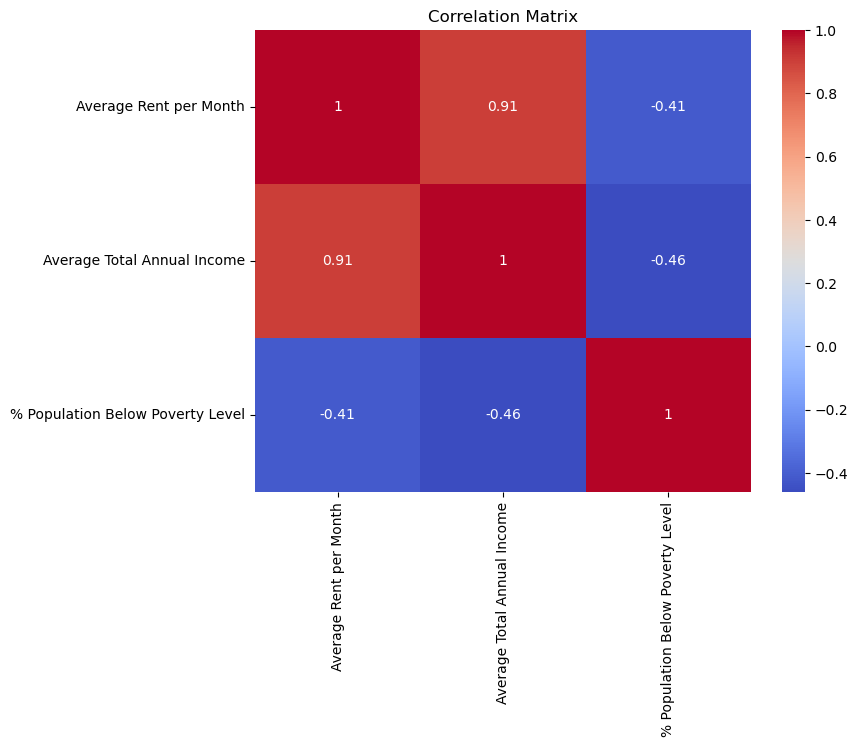

In [ ]:
# Create a list of variables to include in the correlation matrix
corr_vars = [
    "rent_per_month",
    "hh_income",
    "tpoverty",
]

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(panel_df[corr_vars].corr(), annot=True, cmap="coolwarm", 
            xticklabels=[labels[col] for col in corr_vars], 
            yticklabels=[labels[col] for col in corr_vars])
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows a strong positive relationship between average rent and average total annual income (r=0.91), indicating that areas with higher incomes tend to have higher housing costs. In contrast, the percentage of the population below the poverty level is moderately negatively correlated with both income (r=-0.46) and rent (r=-0.41), suggesting that higher-income, higher-rent areas generally have lower poverty rates. Overall, the results reflect a consistent pattern where wealthier areas are associated with higher living costs and reduced levels of poverty.

## 5. Add 2013 HCV Data to HCV Dataset

Since the racial composition data comes in 5-year aggregates, 2013 HCV data is added to account for the additional racial composition data.

In [ ]:
# Set the additional year(s)
bonus_year = 2013

# Store the file path
file_name = "TRACT_MO_WY_2013.xlsx"
file_2013 = os.path.join(data_folder, file_name)

# Process data
try:
    print(f"Processing file: {file_2013}")

    # Load file
    hcv_2013_df = pd.read_excel(file_2013, dtype=str)

    # Filter to HCV program
    hcv_2013_df = hcv_2013_df[hcv_2013_df["program"] == "3"]

    # Keep only needed columns
    hcv_2013_df = hcv_2013_df[[col for col in columns_to_keep if col in df.columns]]

    # Filter tracts and assign treatment
    hcv_2013_df = filter_tracts(hcv_2013_df, treatment_prefixes, control_prefixes, file_2013)

    # Process missing values
    hcv_2013_df = processing_missing_values(hcv_2013_df, file_2013)

    # Add year
    hcv_2013_df = add_year(hcv_2013_df, bonus_year)

    # Create derived variables
    hcv_2013_df = create_variables(hcv_2013_df)

    # Warn if dataset becomes empty
    if df.empty:
        print(f"Warning: {file_2013} resulted in empty dataframe after filtering")
    
except Exception as e:
    print(f"Error processing file: {file_2013}")
    print(e)

# Combine 2013 data with previously processed hud panel
hcv_extended = pd.concat([hcv_2013_df, panel_df], ignore_index=True)

# Drop unused financial variables
hcv_extended = hcv_extended.drop(columns=["rent_per_month", "hh_income"], errors="ignore")

Processing file: data/TRACT_MO_WY_2013.xlsx


In [ ]:
# Show a sample of the HCV dataset with 2013 data included
hcv_extended.sample(5)

,program_label,program,entities,code,number_reported,tpoverty,treatment,year,post,poverty_indicator
5830,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113011200,48113011200,191.0,34.0,1,2022,1,1
4958,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201410100,48201410100,115.0,27.0,0,2020,1,0
5423,Housing Choice Vouchers,3,TX Texas 201 Harris County 48201220500,48201220500,88.0,46.0,0,2021,1,1
246,Housing Choice Vouchers,3,TX Dallas County Census Tract 192.04 48113019204,48113019204,21.0,17.0,1,2013,0,0
2582,Housing Choice Vouchers,3,"TX Texas 201 Harris County, Texas 48201550301",48201550301,400.0,22.0,0,2016,0,0


## 6. Aggregate HCV Dataset

In [12]:
def assign_period(year):
    """
    Assign a five-year period label based on year.

    Parameters:
        year (int): observation year

    Returns:
        str: period label
    """
    if 2013 <= year <= 2017:
        return "2013-2017"
    elif 2018 <= year <= 2022:
        return "2018-2022"
    return np.nan


# Create period variable
hcv_extended["year"] = hcv_extended["year"].astype(int)
hcv_extended["period"] = hcv_extended["year"].apply(assign_period)

# Remove observations outside target periods
hcv_extended = hcv_extended.dropna(subset=["period"])

# Aggregate to tract-period level
hcv_agg = (
    hcv_extended
    .groupby(["code", "period"], as_index=False)
    .agg({
        "number_reported": "mean",
        "tpoverty": "mean"
    })
)

# Recreate poverty indicator from aggregated values
hcv_agg["poverty_indicator"] = (hcv_agg["tpoverty"] >= 30).astype(int)

# Rename period for merge consistency
hcv_agg = hcv_agg.rename(columns={"period": "year"})

hcv_agg.head()

,code,year,number_reported,tpoverty,poverty_indicator
0,48113000401,2013-2017,35.0,35.0,1
1,48113000401,2018-2022,35.2,32.0,1
2,48113000405,2013-2017,17.6,36.8,1
3,48113000405,2018-2022,18.5,26.5,0
4,48113000406,2018-2022,14.75,18.5,0


## 7. Process Racial Composition Data

In [13]:
# Load racial composition datasets for both time periods
rc_1317 = pd.read_csv("data/nhgis0001_ds233_20175_tract.csv", dtype=str)
rc_1822 = pd.read_csv("data/nhgis0003_ds262_20225_tract.csv", dtype=str)

In [14]:
def process_rc(df, rename_dict, year_label):
    """
    Clean and standardize nhgis racial composition data.

    Steps:
        - Select relevant variables
        - Rename race categories
        - Create tract identifier from geoid
        - Filter to treatment and control tracts
        - Convert numeric fields
        - Drop selected race categories
        - Assign period label

    Parameters:
        df (pd.DataFrame): raw nhgis dataset
        rename_dict (dict): column renaming dictionary
        year_label (str): period label

    Returns:
        pd.DataFrame: cleaned racial composition dataset
    """
    # Select required columns
    cols = ["YEAR", "GEOID"] + list(rename_dict.keys())
    df = df[cols]

    # Rename race variables
    df = df.rename(columns=rename_dict)

    # Ensure geoid is string before processing
    df["GEOID"] = df["GEOID"].astype(str).str.strip()

    # Extract tract code (11-digit census tract id)
    df["code"] = df["GEOID"].str.extract(r"(\d{11})")

    # Filter to treatment and control tracts
    valid_prefixes = ("48113", "48201")
    df = df[df["code"].str.startswith(valid_prefixes)]

    # Convert race columns to numeric
    race_cols = list(rename_dict.values())
    for col in race_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop race categories that are underrepresented in the tracts
    df = df.drop(
        columns=[
            "Native_Hawaiian_Pacific_Islander_alone",
            "American_Indian_Alaska_Native_alone"
        ],
        errors="ignore"
    )

    # Assign period label
    df["year"] = year_label

    return df

In [15]:
# Update race/ethnicity variables to have readable names

rename_1317 = {
    "AHY2E001": "Total",
    "AHY2E002": "White_alone",
    "AHY2E003": "Black_or_African_American_alone",
    "AHY2E004": "American_Indian_Alaska_Native_alone",
    "AHY2E005": "Asian_alone",
    "AHY2E006": "Native_Hawaiian_Pacific_Islander_alone",
    "AHY2E007": "Some_other_race_alone",
    "AHY2E008": "Two_or_more_races",
    "AHY2E009": "Two_races_including_some_other_race",
    "AHY2E010": "Two_races_excluding_some_other_and_three_plus"
}

rename_1822 = {
    "AQNGE001": "Total",
    "AQNGE002": "White_alone",
    "AQNGE003": "Black_or_African_American_alone",
    "AQNGE004": "American_Indian_Alaska_Native_alone",
    "AQNGE005": "Asian_alone",
    "AQNGE006": "Native_Hawaiian_Pacific_Islander_alone",
    "AQNGE007": "Some_other_race_alone",
    "AQNGE008": "Two_or_more_races",
    "AQNGE009": "Two_races_including_some_other_race",
    "AQNGE010": "Two_races_excluding_some_other_and_three_plus"
}

In [16]:
# Rename GEO_ID to GEOID for consistency
rc_1822 = rc_1822.rename(columns={"GEO_ID": "GEOID"})

# Process racial composition data
rc_1317_clean = process_rc(rc_1317, rename_1317, "2013-2017")
rc_1822_clean = process_rc(rc_1822, rename_1822, "2018-2022")

In [17]:
# Combine racial composition data into a single dataset

rc_full = pd.concat([rc_1317_clean, rc_1822_clean], ignore_index=True)

rc_full.head()

,YEAR,GEOID,Total,White_alone,Black_or_African_American_alone,Asian_alone,Some_other_race_alone,Two_or_more_races,Two_races_including_some_other_race,Two_races_excluding_some_other_and_three_plus,code,year
0,2013-2017,14000US48113000100,4105,3481,304,128,33,118,20,98,48113000100,2013-2017
1,2013-2017,14000US48113000201,2949,2820,15,0,80,34,0,34,48113000201,2013-2017
2,2013-2017,14000US48113000202,3857,3491,49,101,92,90,0,90,48113000202,2013-2017
3,2013-2017,14000US48113000300,4235,3673,124,221,44,145,40,105,48113000300,2013-2017
4,2013-2017,14000US48113000401,5755,3426,805,758,636,119,24,95,48113000401,2013-2017


## 8. Merge HCV and Racial Composition Datasets

In [18]:
# Combine aggregated HCV data with racial composition data 

final_df = pd.merge(
    hcv_agg,
    rc_full,
    on=["code", "year"],
    how="inner"
)

# Drop unused columns from merged dataset
final_df = final_df.drop(columns=["YEAR", "GEOID"], errors="ignore")

final_df.head()

,code,year,number_reported,tpoverty,poverty_indicator,Total,White_alone,Black_or_African_American_alone,Asian_alone,Some_other_race_alone,Two_or_more_races,Two_races_including_some_other_race,Two_races_excluding_some_other_and_three_plus
0,48113000401,2013-2017,35.0,35.0,1,5755,3426,805,758,636,119,24,95
1,48113000401,2018-2022,35.2,32.0,1,4649,2253,1110,465,356,367,322,45
2,48113000405,2013-2017,17.6,36.8,1,2282,1315,474,279,173,41,0,41
3,48113000405,2018-2022,18.5,26.5,0,1971,845,864,79,21,162,95,67
4,48113000500,2013-2017,23.5,20.5,0,5357,3901,475,377,349,235,0,235


In [19]:
# Show dimensions of the HCV and racial composition dataset
final_df.shape

(1146, 13)

## 9. Save Processed Datasets

In [20]:
# Save HCV dataset
output_path_hcv = os.path.join(data_folder, "clean_hcv_data.csv")
panel_df.to_csv(output_path_hcv, index=False)

print(f"Cleaned HCV dataset saved to: {output_path_hcv}")

# Save HCV and racial composition dataset
output_path_full = os.path.join(data_folder, "clean_rc_data.csv")
final_df.to_csv(output_path_full, index=False)

print(f"Cleaned HCV and racial composition dataset saved to: {output_path_full}")

Cleaned HCV dataset saved to: data/clean_hcv_data.csv
Cleaned HCV and racial composition dataset saved to: data/clean_rc_data.csv
